In [1]:
import brainpy as bp
import brainpy.math as bm
import numpy as np
import matplotlib.pyplot as plt

/home/brendan/OneDrive/Masters/Code/Vortices/Julia/WRCircuit/.CondaPkg/env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# FNS circuit parameters
tau_d = 5 # ms. 3 for inh.
tau_r = 1 # ms. The synaptic spike width time constant
V_rev = 0 # mV. -80 mV for inhibitory

# Conversions to brainpy AMPA parameters
beta = 1/tau_d
T_dur = tau_r
T = 1/tau_r
alpha = 1.0 # For FNS. Default brainpy is 0.98

# ampa = bp.dyn.AMPA.desc(num_pre, alpha=alpha, beta=beta, T=T, T_dur=T_dur)
# * How to add conduction delays?

In [83]:
class FNSAMPA(bp.Projection):
    def __init__(self, pre, post, delay, conn, g_max=1., tau_d=5, tau_r=1, V_rev=0., alpha=1.0):
        super().__init__()
        self.proj = bp.dyn.FullProjAlignPreSDMg(
          pre=pre,
          delay=delay,
          syn=bp.dyn.AMPA.desc(pre.num, alpha=alpha, beta=1/tau_d, T=1/tau_r, T_dur=tau_r),
          comm=bp.dnn.CSRLinear(conn, g_max),
          out=bp.dyn.COBA(E=V_rev),
          post=post,
        )

In [ ]:
class AMPA(bp.Projection):
    def __init__(self, pre, post, delay, prob, g_max, E=0.):
        super().__init__()
        conn = bp.conn.FixedProb(prob, pre=pre.num, post=post.num)
        self.proj = bp.dyn.FullProjAlignPreSDMg(
          pre=pre,
          delay=delay,
          syn=bp.dyn.AMPA.desc(pre.num, alpha=alpha, beta=beta, T=T, T_dur=T_dur),
          comm=bp.dnn.CSRLinear(conn, g_max),
          out=bp.dyn.COBA(E=V_rev), # E is the reversal threshold
          post=post,
        )

In [84]:
class SimpleNet(bp.DynSysGroup):
    def __init__(self, E=0.):
        super().__init__()

        self.pre = bp.dyn.SpikeTimeGroup(1, indices=(0, 0, 0, 0, 0, 0), times=(10., 30., 40., 40., 60., 70.))
        self.post = bp.dyn.LifRef(1, V_rest=-60., V_th=-50., V_reset=-60., tau=20., tau_ref=5.,
                                  V_initializer=bp.init.Constant(-60.))
        self.syn = AMPA(self.pre, self.post, delay=None, prob=1., g_max=1., E=E)

    def update(self):
        self.pre()
        self.syn()
        self.post()

        # monitor the following variables
        conductance = self.syn.proj.refs['syn'].g
        current = self.post.sum_inputs(self.post.V)
        return conductance, current, self.post.V

  0%|          | 0/1000 [00:00<?, ?it/s]/home/brendan/OneDrive/Masters/Code/Vortices/Julia/WRCircuit/.CondaPkg/env/lib/python3.11/site-packages/brainpy/_src/mixin.py:489: UserWarning: Please use ".sum_current_inputs()" instead. ".sum_inputs()" will be removed.
  warnings.warn('Please use ".sum_current_inputs()" instead. ".sum_inputs()" will be removed.', UserWarning)
/home/brendan/OneDrive/Masters/Code/Vortices/Julia/WRCircuit/.CondaPkg/env/lib/python3.11/site-packages/brainpy/_src/mixin.py:489: UserWarning: Please use ".sum_current_inputs()" instead. ".sum_inputs()" will be removed.
  warnings.warn('Please use ".sum_current_inputs()" instead. ".sum_inputs()" will be removed.', UserWarning)
100%|██████████| 1000/1000 [00:00<00:00, 8822.65it/s]


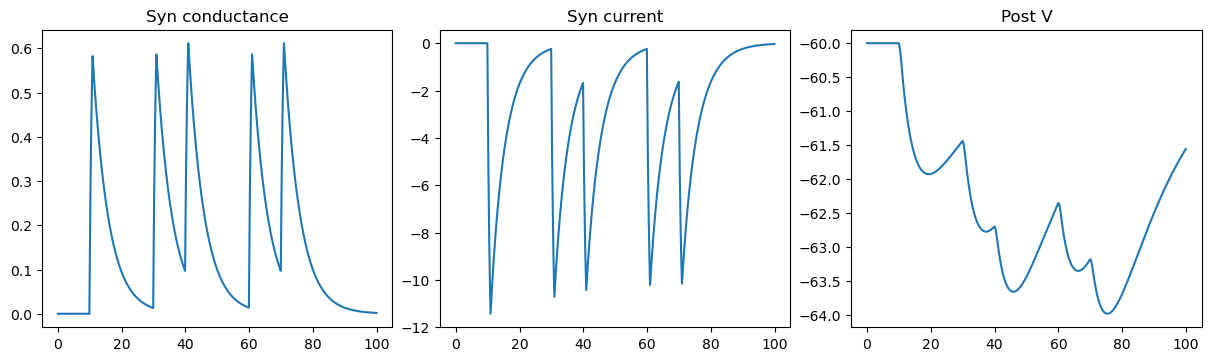

In [85]:
indices = np.arange(1000)  # 100 ms, dt= 0.1 ms
conductances, currents, potentials = bm.for_loop(SimpleNet(E=0.).step_run, indices, progress_bar=True)
ts = indices * bm.get_dt()


fig, gs = bp.visualize.get_figure(1, 3, 3.5, 4)
fig.add_subplot(gs[0, 0])
plt.plot(ts, conductances)
plt.title('Syn conductance')
fig.add_subplot(gs[0, 1])
plt.plot(ts, currents)
plt.title('Syn current')
fig.add_subplot(gs[0, 2])
plt.plot(ts, potentials)
plt.title('Post V')
plt.show()